# Phase 1 — Simulated GRB Detection Pipeline

This notebook demonstrates the Phase 1 implementation of **grbtrace**:
- synthetic GRB light curve generation
- threshold-based burst detection
- T90 feature extraction
- visualization

No real telescope data is used yet.

In [46]:
%cd /content
!rm -rf grbtrace
!git clone https://github.com/rshahri/grbtrace.git
%cd /content/grbtrace
!pip -q install numpy scipy matplotlib pytest

/content
Cloning into 'grbtrace'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 41 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 61.23 KiB | 4.71 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/grbtrace


In [47]:
from simulate import simulate_binned_lightcurve
from detect import detect_burst_threshold
from features import compute_t90, peak_rate, fluence_proxy
from plot import plot_lightcurve

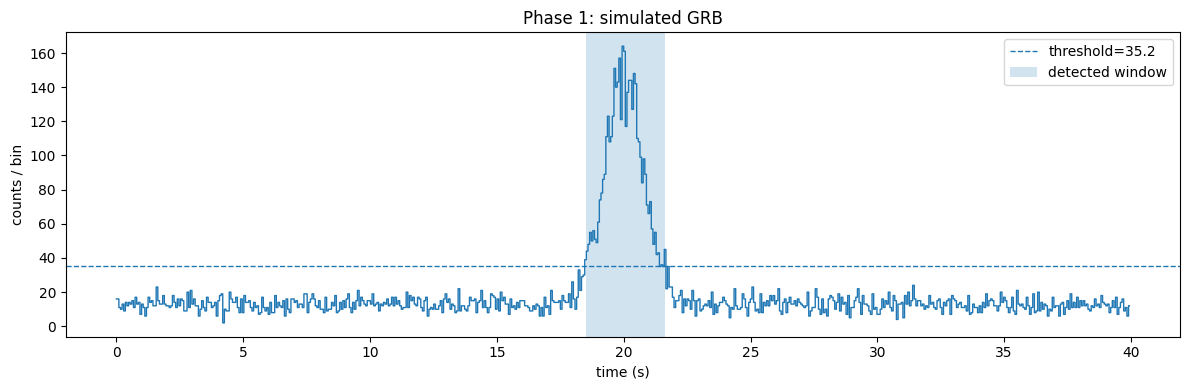

=== Detection ===
Window: 18.496s → 21.632s

=== Features ===
T90: 2.520s
Peak rate: 2562.5 counts/s
Fluence proxy: 12096 counts


In [48]:
t, counts, dt = simulate_binned_lightcurve()
det = detect_burst_threshold(counts, sigma=5.0)

if det is None:
    print("No burst detected.")
    plot_lightcurve(t, counts, title="Simulated light curve")
else:
    window = (t[det.start_idx], t[det.end_idx])
    t90res = compute_t90(t, counts, det.start_idx, det.end_idx)

    plot_lightcurve(t, counts, threshold=det.threshold, window=window, title="Phase 1: simulated GRB")

    print("=== Detection ===")
    print(f"Window: {window[0]:.3f}s → {window[1]:.3f}s")

    print("\n=== Features ===")
    if t90res:
        print(f"T90: {t90res.t90:.3f}s")
        print(f"Peak rate: {peak_rate(counts, dt):.1f} counts/s")
        print(f"Fluence proxy: {fluence_proxy(counts):.0f} counts")

In [49]:
!pytest -q

.                                                                        [100%]
1 passed in 0.10s
